# GMFlow — Confusion Matrix · ROC (200개) · **로컬 노트북**

GPU 없이 **PC에서 이 노트북만** 실행합니다.

## 준비
1. 터미널: `pip install matplotlib seaborn scikit-learn numpy pandas`
2. **방법 A (권장)** — AWS CLI 설정 후 Run All → S3에서 `infer_summary` 자동 다운로드
3. **방법 B** — Downloads에 JSON 2개 준비 후 **셀 2** `LOCAL_FILES` 경로 지정

| profile | S3 RUN | 비고 |
|---------|--------|------|
| ffpp_vox | `gmflow-ffpp-vox-benchmark-20260622-0544` | `infer_summary`에 `fake_score` 포함 |
| celebdf | `gmflow-celebdf-benchmark-20260622-0142` | `json/`에서 `motion_anomaly_score` 병합 |

**점수:** `fake_score` (= `motion_anomaly_score` heuristic). CNN `prob_fake`와 비교하지 마세요.

출력 PNG: `output/gmflow-cm/` (`cm_gmflow_200_*.png`, `roc_gmflow_200_*.png`)

팀 CM 표기: [09-CNN-벤치마크-Confusion-Matrix-ROC.md](../09-CNN-벤치마크-Confusion-Matrix-ROC.md) 부록

상세: [GMFLOW_DEEPFAKE_SCORE.md](../../GMFLOW_DEEPFAKE_SCORE.md)

> **갱신:** 2026-06-22 — ffpp_vox + celebdf 200 CM/ROC (S3 `video-benchmark-datasets/gmflow`)


In [ ]:
# 첫 실행 시 주석 해제:
#!pip install matplotlib seaborn scikit-learn numpy pandas

import json
import subprocess
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import auc, classification_report, confusion_matrix, roc_curve

import matplotlib as mpl
import matplotlib.font_manager as fm


def _setup_korean_font() -> str:
    """CM 축 라벨(가짜/진짜) 한글이 □로 깨지지 않게 폰트 설정."""
    candidates = [
        "Malgun Gothic",
        "NanumGothic",
        "Nanum Gothic",
        "AppleGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    mpl.rcParams["axes.unicode_minus"] = False
    return "default (Korean font not found — install Malgun Gothic or NanumGothic)"


_kr_font = _setup_korean_font()
print(f"matplotlib font: {_kr_font}")

NOTEBOOK_DIR = Path(r"c:\Final_Project\ai\ai-forensic\docs\notebooks\output")
CACHE_DIR = NOTEBOOK_DIR / ".gmflow_cache"
OUT_DIR = NOTEBOOK_DIR / "output" / "gmflow-cm"
OUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

S3_BASE = (
    "s3://forenshield-evidence-877044078824/"
    "cases/test/video-benchmark-datasets/gmflow"
)

PROFILES = {
    "ffpp_vox": {
        "infer_summary": (
            f"{S3_BASE}/ffpp_vox/gmflow-ffpp-vox-benchmark-20260622-0544/infer_summary.json"
        ),
        "json_prefix": (
            f"{S3_BASE}/ffpp_vox/gmflow-ffpp-vox-benchmark-20260622-0544/json/"
        ),
        "needs_json_merge": False,
    },
    "celebdf": {
        "infer_summary": (
            f"{S3_BASE}/celebdf/gmflow-celebdf-benchmark-20260622-0142/infer_summary.json"
        ),
        "json_prefix": (
            f"{S3_BASE}/celebdf/gmflow-celebdf-benchmark-20260622-0142/json/"
        ),
        "needs_json_merge": True,
    },
}

# 로컬 JSON이 있으면 경로 지정 (None이면 S3/캐시 사용)
LOCAL_FILES = {
    "ffpp_vox": None,
    "celebdf": None,
}
LOCAL_JSON_DIRS = {
    "ffpp_vox": None,
    "celebdf": None,
}

LABELS_TEAM = ["fake", "real"]
THRESHOLD = 0.5
MODEL_LABEL = "GMFlow (motion heuristic)"
SCORE_FIELD = "fake_score"

print(f"OUT_DIR: {OUT_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")


matplotlib font: Malgun Gothic
OUT_DIR: c:\Final_Project\ai\ai-forensic\docs\notebooks\output\output\gmflow-cm
CACHE_DIR: c:\Final_Project\ai\ai-forensic\docs\notebooks\output\.gmflow_cache


In [2]:
def _aws_cp(s3_uri: str, local_path: Path) -> None:
    local_path.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["aws", "s3", "cp", s3_uri, str(local_path)],
        check=True,
        capture_output=True,
        text=True,
    )


def _aws_sync(s3_prefix: str, local_dir: Path) -> None:
    local_dir.mkdir(parents=True, exist_ok=True)
    subprocess.run(
        ["aws", "s3", "sync", s3_prefix, str(local_dir)],
        check=True,
        capture_output=True,
        text=True,
    )


def _resolve_infer_summary(profile: str) -> Path:
    local_override = LOCAL_FILES.get(profile)
    if local_override and Path(local_override).is_file():
        return Path(local_override)

    cached = CACHE_DIR / profile / "infer_summary.json"
    if cached.is_file():
        return cached

    s3_uri = PROFILES[profile]["infer_summary"]
    print(f"downloading {profile} infer_summary from s3...")
    _aws_cp(s3_uri, cached)
    return cached


def _load_json_scores(profile: str) -> dict[str, dict]:
    cfg = PROFILES[profile]
    if not cfg["needs_json_merge"]:
        return {}

    local_json = LOCAL_JSON_DIRS.get(profile)
    if local_json and Path(local_json).is_dir():
        json_dir = Path(local_json)
    else:
        json_dir = CACHE_DIR / profile / "json"
        if not any(json_dir.glob("*.json")):
            print(f"syncing {profile} json/ from s3...")
            _aws_sync(cfg["json_prefix"], json_dir)

    by_stem: dict[str, dict] = {}
    for path in json_dir.glob("*.json"):
        by_stem[path.stem] = json.loads(path.read_text(encoding="utf-8"))
    return by_stem


def _merge_score_fields(item: dict, json_scores: dict[str, dict], threshold: float) -> dict:
    out = dict(item)
    if out.get(SCORE_FIELD) is not None:
        return out

    stem = Path(out.get("file", "")).stem
    detail = json_scores.get(stem)
    if not detail:
        return out

    mas = detail.get("motion_anomaly_score")
    if mas is None:
        mas = detail.get("fake_score")
    if mas is not None:
        out["motion_anomaly_score"] = mas
        out[SCORE_FIELD] = mas
        out["pred_label"] = detail.get("pred_label") or (
            "fake" if float(mas) >= threshold else "real"
        )
    return out


def load_profile_items(profile: str, threshold: float = THRESHOLD) -> list[dict]:
    summary_path = _resolve_infer_summary(profile)
    data = json.loads(summary_path.read_text(encoding="utf-8"))
    json_scores = _load_json_scores(profile)

    items: list[dict] = []
    for raw in data.get("items", []):
        items.append(_merge_score_fields(raw, json_scores, threshold))

    scored = [it for it in items if it.get(SCORE_FIELD) is not None]
    print(
        f"gmflow / {profile} / n={len(items)} scored={len(scored)}  ({summary_path.name})"
    )
    if len(scored) < len(items):
        missing = [it.get("file") for it in items if it.get(SCORE_FIELD) is None]
        print(f"  warning: missing {SCORE_FIELD} for {len(missing)} items: {missing[:5]}")
    return scored


items_ffpp = load_profile_items("ffpp_vox")
items_celeb = load_profile_items("celebdf")
items_all = items_ffpp + items_celeb

print(f"total scored: {len(items_all)}")

y_true = [it["ground_truth_label"] for it in items_all]
y_pred = [it["pred_label"] for it in items_all]


gmflow / ffpp_vox / n=100 scored=100  (infer_summary.json)
gmflow / celebdf / n=100 scored=100  (infer_summary.json)
total scored: 200


saved c:\Final_Project\ai\ai-forensic\docs\notebooks\output\output\gmflow-cm\cm_gmflow_200_combined.png


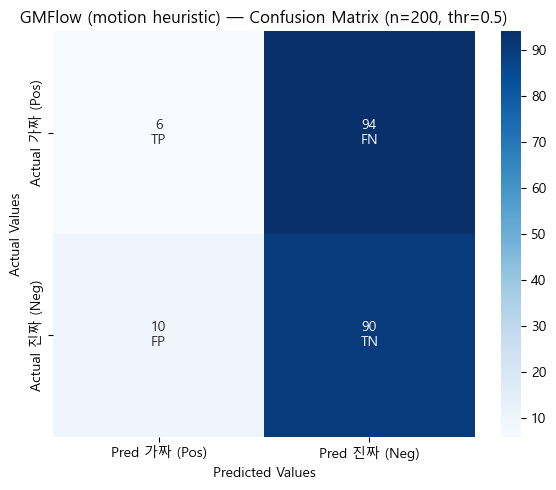

CM (rows=fake,real):
 [[ 6 94]
 [10 90]]
              precision    recall  f1-score   support

        fake      0.375     0.060     0.103       100
        real      0.489     0.900     0.634       100

    accuracy                          0.480       200
   macro avg      0.432     0.480     0.369       200
weighted avg      0.432     0.480     0.369       200



In [3]:
def plot_team_cm(y_true, y_pred, title: str, out_path: Path | None = None):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_TEAM)
    tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

    annot = np.array([[f"{tp}\nTP", f"{fn}\nFN"], [f"{fp}\nFP", f"{tn}\nTN"]])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred 가짜 (Pos)", "Pred 진짜 (Neg)"],
        yticklabels=["Actual 가짜 (Pos)", "Actual 진짜 (Neg)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Actual Values")
    ax.set_title(title)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return cm


cm200 = plot_team_cm(
    y_true,
    y_pred,
    title=f"{MODEL_LABEL} — Confusion Matrix (n={len(items_all)}, thr={THRESHOLD})",
    out_path=OUT_DIR / "cm_gmflow_200_combined.png",
)
print("CM (rows=fake,real):\n", cm200)
print(classification_report(y_true, y_pred, labels=LABELS_TEAM, digits=3))


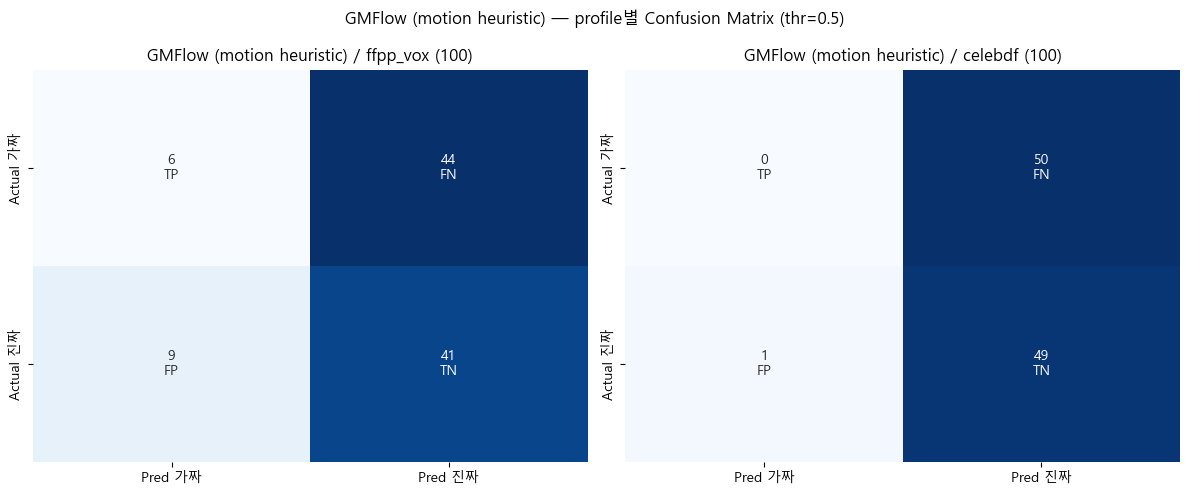

saved c:\Final_Project\ai\ai-forensic\docs\notebooks\output\output\gmflow-cm\cm_gmflow_200_by_profile.png


In [4]:
# (선택) 프로필별 2장 — ffpp_vox vs celebdf 비교용
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, items in [
    (axes[0], "ffpp_vox (100)", items_ffpp),
    (axes[1], "celebdf (100)", items_celeb),
]:
    yt = [it["ground_truth_label"] for it in items]
    yp = [it["pred_label"] for it in items]
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    annot = np.array(
        [[f"{cm[0,0]}\nTP", f"{cm[0,1]}\nFN"], [f"{cm[1,0]}\nFP", f"{cm[1,1]}\nTN"]]
    )
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=["Pred 가짜", "Pred 진짜"],
        yticklabels=["Actual 가짜", "Actual 진짜"],
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"{MODEL_LABEL} / {name}")
fig.suptitle(f"{MODEL_LABEL} — profile별 Confusion Matrix (thr={THRESHOLD})")
fig.tight_layout()
split_path = OUT_DIR / "cm_gmflow_200_by_profile.png"
fig.savefig(split_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {split_path}")


## ROC Curve (200개)

**Positive = 가짜(`fake`)** · 점수 = `fake_score` (= motion_anomaly_score, 0~1)

| 축 | 의미 |
|------|------|
| TPR (세로) | 재현도 — 실제 가짜 중 가짜로 판정한 비율 |
| FPR (가로) | 오탐률 — 실제 진짜 중 가짜로 오판한 비율 |

**AUC** (곡선 아래 면적): 1에 가까울수록 좋음. 점선은 랜덤(0.5). ● = threshold 0.5 지점.

> CNN `prob_fake`와 달리 학습된 분류 확률이 아닌 **motion heuristic** 점수입니다.


saved c:\Final_Project\ai\ai-forensic\docs\notebooks\output\output\gmflow-cm\roc_gmflow_200_combined.png


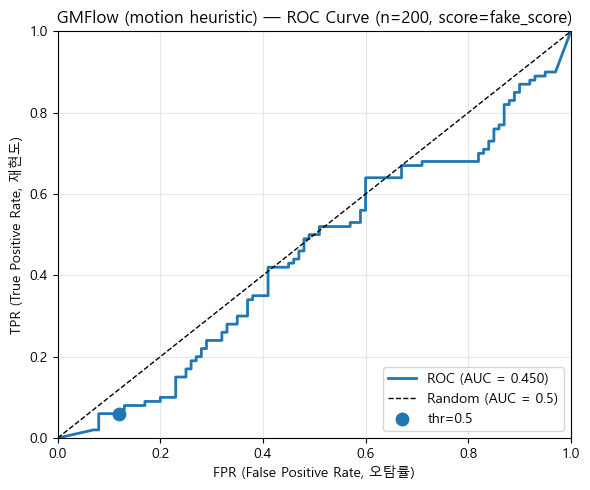

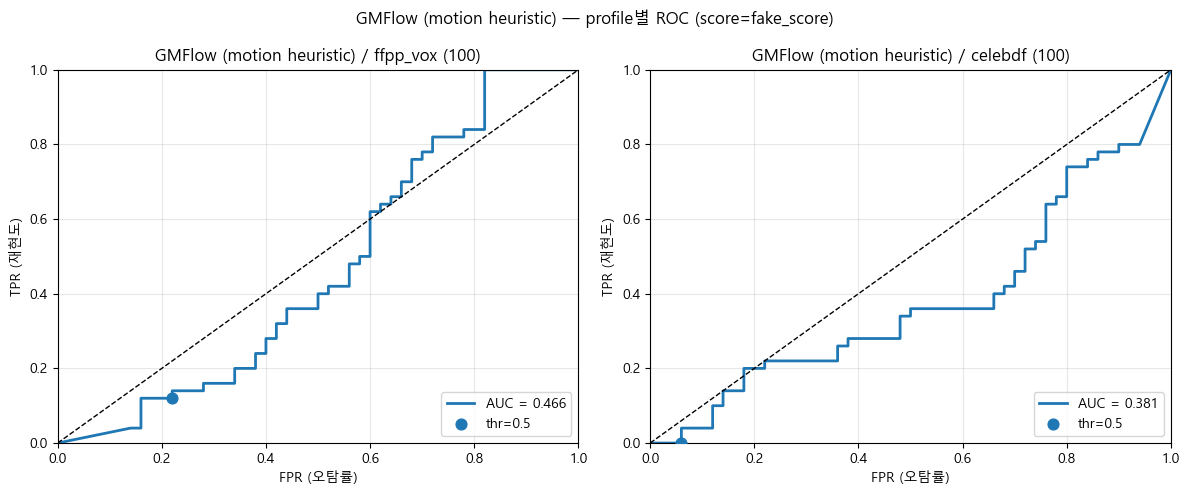

saved c:\Final_Project\ai\ai-forensic\docs\notebooks\output\output\gmflow-cm\roc_gmflow_200_by_profile.png


,구분,AUC,n
0,200 combined,0.4500,200
1,ffpp_vox,0.4656,100
2,celebdf,0.3812,100


In [5]:
import pandas as pd


def items_to_roc_arrays(items) -> tuple[np.ndarray, np.ndarray]:
    """Positive=fake(1), score=fake_score."""
    y = np.array([1 if it["ground_truth_label"] == "fake" else 0 for it in items])
    s = np.array([float(it[SCORE_FIELD]) for it in items])
    return y, s


def plot_roc_single(items, title: str, out_path: Path | None = None, thr: float = THRESHOLD) -> float:
    y, s = items_to_roc_arrays(items)
    fpr, tpr, thresholds = roc_curve(y, s, pos_label=1)
    roc_auc = auc(fpr, tpr)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(fpr, tpr, lw=2, label=f"ROC (AUC = {roc_auc:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC = 0.5)")

    if len(thresholds) > 0:
        idx = int(np.argmin(np.abs(thresholds - thr)))
        ax.scatter(fpr[idx], tpr[idx], s=80, zorder=5, label=f"thr={thr}")

    ax.set_xlabel("FPR (False Positive Rate, 오탐률)")
    ax.set_ylabel("TPR (True Positive Rate, 재현도)")
    ax.set_title(title)
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return roc_auc


auc200 = plot_roc_single(
    items_all,
    f"{MODEL_LABEL} — ROC Curve (n={len(items_all)}, score={SCORE_FIELD})",
    OUT_DIR / "roc_gmflow_200_combined.png",
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
auc_rows = []
for ax, name, items in [
    (axes[0], "ffpp_vox (100)", items_ffpp),
    (axes[1], "celebdf (100)", items_celeb),
]:
    y, s = items_to_roc_arrays(items)
    fpr, tpr, thresholds = roc_curve(y, s, pos_label=1)
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"AUC = {a:.3f}")
    ax.plot([0, 1], [0, 1], "k--", lw=1)
    if len(thresholds) > 0:
        idx = int(np.argmin(np.abs(thresholds - THRESHOLD)))
        ax.scatter(fpr[idx], tpr[idx], s=60, zorder=5, label=f"thr={THRESHOLD}")
    ax.set_xlabel("FPR (오탐률)")
    ax.set_ylabel("TPR (재현도)")
    ax.set_title(f"{MODEL_LABEL} / {name}")
    ax.legend(loc="lower right")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)
    profile = name.split()[0]
    auc_rows.append({"구분": profile, "AUC": f"{a:.4f}", "n": len(items)})

fig.suptitle(f"{MODEL_LABEL} — profile별 ROC (score={SCORE_FIELD})")
fig.tight_layout()
split_roc = OUT_DIR / "roc_gmflow_200_by_profile.png"
fig.savefig(split_roc, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {split_roc}")

roc_summary = pd.DataFrame(
    [{"구분": "200 combined", "AUC": f"{auc200:.4f}", "n": len(items_all)}] + auc_rows
)
display(roc_summary)


## 분류 지표 추출 (Accuracy · Precision · Recall · F1)

Confusion Matrix에서 TP/FN/FP/TN을 읽어 [부록 B](../09-CNN-벤치마크-Confusion-Matrix-ROC.md#부록-b--accuracy--precision--recall--f1-score) 공식으로 계산합니다.

**Positive = 가짜(`fake`)** 기준:

| 지표 | 공식 |
|------|------|
| Accuracy(정확도) | (TP + TN) / (TP + FN + FP + TN) |
| Precision(정밀도) | TP / (TP + FP) |
| Recall(재현도) | TP / (TP + FN) |
| F1-Score(조화평균) | 2 × Precision(정밀도) × Recall(재현도) / (Precision(정밀도) + Recall(재현도)) |


In [6]:
import pandas as pd
from IPython.display import Markdown, display


def metrics_from_cm(cm: np.ndarray) -> dict:
    tp, fn, fp, tn = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    total = tp + fn + fp + tn
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "TP": tp, "FN": fn, "FP": fp, "TN": tn, "n": total,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "acc_num": tp + tn,
        "acc_den": total,
        "prec_num": tp,
        "prec_den": tp + fp,
        "rec_num": tp,
        "rec_den": tp + fn,
        "f1_num": 2 * tp,
        "f1_den": 2 * tp + fp + fn,
    }


def metrics_table(m: dict) -> pd.DataFrame:
    rows = [
        {
            "지표": "Accuracy(정확도)",
            "분자": f"TP + TN = {m['TP']} + {m['TN']} = {m['acc_num']}",
            "분모": f"TP + FN + FP + TN = {m['n']}",
            "수식": f"{m['acc_num']} / {m['acc_den']}",
            "값": f"{m['accuracy']:.4f}",
            "백분율": f"{m['accuracy'] * 100:.2f}%",
        },
        {
            "지표": "Precision(정밀도)",
            "분자": f"TP = {m['prec_num']}",
            "분모": f"TP + FP = {m['TP']} + {m['FP']} = {m['prec_den']}",
            "수식": f"{m['prec_num']} / {m['prec_den']}",
            "값": f"{m['precision']:.4f}",
            "백분율": f"{m['precision'] * 100:.2f}%",
        },
        {
            "지표": "Recall(재현도)",
            "분자": f"TP = {m['rec_num']}",
            "분모": f"TP + FN = {m['TP']} + {m['FN']} = {m['rec_den']}",
            "수식": f"{m['rec_num']} / {m['rec_den']}",
            "값": f"{m['recall']:.4f}",
            "백분율": f"{m['recall'] * 100:.2f}%",
        },
        {
            "지표": "F1-Score(조화평균)",
            "분자": f"2 × TP = 2 × {m['TP']} = {m['f1_num']}",
            "분모": f"2×TP + FP + FN = {m['f1_den']}",
            "수식": f"{m['f1_num']} / {m['f1_den']}",
            "값": f"{m['f1']:.4f}",
            "백분율": f"{m['f1'] * 100:.2f}%",
        },
    ]
    return pd.DataFrame(rows)


def display_metrics_block(label: str, yt, yp) -> dict:
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    m = metrics_from_cm(cm)
    tp, fn, fp, tn = m["TP"], m["FN"], m["FP"], m["TN"]

    display(Markdown(f"### {label}  \n**n = {m['n']}** · Positive = fake (가짜)"))
    display(Markdown(
        f"""
| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = {tp}** | FN = {fn} |
| **Actual real** | FP = {fp} | **TN = {tn}** |
"""
    ))
    display(metrics_table(m))

    display(Markdown(
        f"""
**LaTeX 형태**

$$
\\text{{Accuracy(정확도)}} = \\frac{{TP + TN}}{{TP + FN + FP + TN}}
= \\frac{{{tp} + {tn}}}{{{m['n']}}}
= \\frac{{{m['acc_num']}}}{{{m['acc_den']}}}
= {m['accuracy']:.4f}
$$

$$
\\text{{Precision(정밀도)}} = \\frac{{TP}}{{TP + FP}}
= \\frac{{{tp}}}{{{tp} + {fp}}}
= \\frac{{{m['prec_num']}}}{{{m['prec_den']}}}
= {m['precision']:.4f}
$$

$$
\\text{{Recall(재현도)}} = \\frac{{TP}}{{TP + FN}}
= \\frac{{{tp}}}{{{tp} + {fn}}}
= \\frac{{{m['rec_num']}}}{{{m['rec_den']}}}
= {m['recall']:.4f}
$$

$$
\text{{F1-Score(조화평균)}} = \\frac{{2 \\times \\text{{Precision(정밀도)}} \\times \\text{{Recall(재현도)}}}}{{\\text{{Precision(정밀도)}} + \\text{{Recall(재현도)}}}}
= \\frac{{2 \\times TP}}{{2 \\times TP + FP + FN}}
= \\frac{{{m['f1_num']}}}{{{m['f1_den']}}}
= {m['f1']:.4f}
$$
"""
    ))
    return m


yt_ffpp = [it["ground_truth_label"] for it in items_ffpp]
yp_ffpp = [it["pred_label"] for it in items_ffpp]
yt_celeb = [it["ground_truth_label"] for it in items_celeb]
yp_celeb = [it["pred_label"] for it in items_celeb]

m_all = display_metrics_block("GMFlow 200 (ffpp_vox + celebdf)", y_true, y_pred)
m_ffpp = display_metrics_block("GMFlow · ffpp_vox", yt_ffpp, yp_ffpp)
m_celeb = display_metrics_block("GMFlow · celebdf", yt_celeb, yp_celeb)

summary = pd.DataFrame([
    {
        "구분": "200 combined",
        "TP": m_all["TP"], "FN": m_all["FN"], "FP": m_all["FP"], "TN": m_all["TN"],
        "Accuracy(정확도)": f"{m_all['acc_num']}/{m_all['acc_den']} = {m_all['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_all['prec_num']}/{m_all['prec_den']} = {m_all['precision']:.3f}",
        "Recall(재현도)": f"{m_all['rec_num']}/{m_all['rec_den']} = {m_all['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_all['f1_num']}/{m_all['f1_den']} = {m_all['f1']:.3f}",
    },
    {
        "구분": "ffpp_vox",
        "TP": m_ffpp["TP"], "FN": m_ffpp["FN"], "FP": m_ffpp["FP"], "TN": m_ffpp["TN"],
        "Accuracy(정확도)": f"{m_ffpp['acc_num']}/{m_ffpp['acc_den']} = {m_ffpp['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_ffpp['prec_num']}/{m_ffpp['prec_den']} = {m_ffpp['precision']:.3f}",
        "Recall(재현도)": f"{m_ffpp['rec_num']}/{m_ffpp['rec_den']} = {m_ffpp['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_ffpp['f1_num']}/{m_ffpp['f1_den']} = {m_ffpp['f1']:.3f}",
    },
    {
        "구분": "celebdf",
        "TP": m_celeb["TP"], "FN": m_celeb["FN"], "FP": m_celeb["FP"], "TN": m_celeb["TN"],
        "Accuracy(정확도)": f"{m_celeb['acc_num']}/{m_celeb['acc_den']} = {m_celeb['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_celeb['prec_num']}/{m_celeb['prec_den']} = {m_celeb['precision']:.3f}",
        "Recall(재현도)": f"{m_celeb['rec_num']}/{m_celeb['rec_den']} = {m_celeb['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_celeb['f1_num']}/{m_celeb['f1_den']} = {m_celeb['f1']:.3f}",
    },
])

display(Markdown("### 전체 요약"))
display(summary)


### GMFlow 200 (ffpp_vox + celebdf)  
**n = 200** · Positive = fake (가짜)


| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = 6** | FN = 94 |
| **Actual real** | FP = 10 | **TN = 90** |


,지표,분자,분모,수식,값,백분율
0,Accuracy(정확도),TP + TN = 6 + 90 = 96,TP + FN + FP + TN = 200,96 / 200,0.4800,48.00%
1,Precision(정밀도),TP = 6,TP + FP = 6 + 10 = 16,6 / 16,0.3750,37.50%
2,Recall(재현도),TP = 6,TP + FN = 6 + 94 = 100,6 / 100,0.0600,6.00%
3,F1-Score(조화평균),2 × TP = 2 × 6 = 12,2×TP + FP + FN = 116,12 / 116,0.1034,10.34%



**LaTeX 형태**

$$
\text{Accuracy(정확도)} = \frac{TP + TN}{TP + FN + FP + TN}
= \frac{6 + 90}{200}
= \frac{96}{200}
= 0.4800
$$

$$
\text{Precision(정밀도)} = \frac{TP}{TP + FP}
= \frac{6}{6 + 10}
= \frac{6}{16}
= 0.3750
$$

$$
\text{Recall(재현도)} = \frac{TP}{TP + FN}
= \frac{6}{6 + 94}
= \frac{6}{100}
= 0.0600
$$

$$
	ext{F1-Score(조화평균)} = \frac{2 \times \text{Precision(정밀도)} \times \text{Recall(재현도)}}{\text{Precision(정밀도)} + \text{Recall(재현도)}}
= \frac{2 \times TP}{2 \times TP + FP + FN}
= \frac{12}{116}
= 0.1034
$$


### GMFlow · ffpp_vox  
**n = 100** · Positive = fake (가짜)

...


| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = 0** | FN = 50 |
| **Actual real** | FP = 1 | **TN = 49** |


,지표,분자,분모,수식,값,백분율
0,Accuracy(정확도),TP + TN = 0 + 49 = 49,TP + FN + FP + TN = 100,49 / 100,0.4900,49.00%
1,Precision(정밀도),TP = 0,TP + FP = 0 + 1 = 1,0 / 1,0.0000,0.00%
2,Recall(재현도),TP = 0,TP + FN = 0 + 50 = 50,0 / 50,0.0000,0.00%
3,F1-Score(조화평균),2 × TP = 2 × 0 = 0,2×TP + FP + FN = 51,0 / 51,0.0000,0.00%



**LaTeX 형태**

$$
\text{Accuracy(정확도)} = \frac{TP + TN}{TP + FN + FP + TN}
= \frac{0 + 49}{100}
= \frac{49}{100}
= 0.4900
$$

$$
\text{Precision(정밀도)} = \frac{TP}{TP + FP}
= \frac{0}{0 + 1}
= \frac{0}{1}
= 0.0000
$$

$$
\text{Recall(재현도)} = \frac{TP}{TP + FN}
= \frac{0}{0 + 50}
= \frac{0}{50}
= 0.0000
$$

$$
	ext{F1-Score(조화평균)} = \frac{2 \times \text{Precision(정밀도)} \times \text{Recall(재현도)}}{\text{Precision(정밀도)} + \text{Recall(재현도)}}
= \frac{2 \times TP}{2 \times TP + FP + FN}
= \frac{0}{51}
= 0.0000
$$


### 전체 요약

,구분,TP,FN,FP,TN,Accuracy(정확도),Precision(정밀도),Recall(재현도),F1-Score(조화평균)
0,200 combined,6,94,10,90,96/200 = 0.480,6/16 = 0.375,6/100 = 0.060,12/116 = 0.103
1,ffpp_vox,6,44,9,41,47/100 = 0.470,6/15 = 0.400,6/50 = 0.120,12/65 = 0.185
2,celebdf,0,50,1,49,49/100 = 0.490,0/1 = 0.000,0/50 = 0.000,0/51 = 0.000
